In [1]:
%matplotlib widget

In [2]:
%load_ext autoreload

In [3]:


import panel as pn
from IPython.display import display

In [4]:
from libertem.api import Context

from microscope_calibration.ui import CoordinateCorrectionLayout
from microscope_calibration.util import jeol_dm4
from microscope_calibration.util.diffraction import get_twothetas

In [5]:
pn.extension('tabulator')

In [7]:
ctx = Context()

/home/weber/miniforge3/envs/calib314/lib/python3.14/site-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43205 instead
  warnings.warn(


In [8]:
structure_filename = 'AuEntryWithCollCode163723.cif'

In [9]:
defocused_wide = jeol_dm4.CalibratedJEOLDM4.load('../examples/defocused_wide.json')

In [10]:
# calibrated = jeol_dm4.CalibratedJEOLDM4.load('defocused_wide.json')
# descan = calibrated.derive_relative_for('/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag60kX_cl80cm_ca20um_z30um_vac.dm4')

In [11]:
%autoreload
# We assume it is constant over the series
acceleration_voltage = jeol_dm4.acceleration_from_dm4(defocused_wide.dm4)

In [12]:
%autoreload
twothetas = get_twothetas(structure_filename, acceleration_voltage.to('V').magnitude, reciprocal_radius=1)
twothetas

array([0.     , 0.01066, 0.01232, 0.01742, 0.02044, 0.02134, 0.02464])

In [13]:
# Calibration sample with 2160 lines per mm
grid = 1e-3 / 2160
grid * 1e9

462.962962962963

In [14]:
grid * 1e9 * 2, grid * 1e9 * 5, grid * 1e9 * 6

(925.925925925926, 2314.814814814815, 2777.777777777778)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(label='Scan rotation / degrees', name='Scan rotation / degrees')
        [1] FloatInput(label='Detector pixel p..., name='Detector pixel p..., value=59.99999999999999)
        [2] FloatInput(label='Camera length / m', name='Camera length / m', step=0.01, value=1.26)
        [3] FloatInput(label='Convergence s..., name='Convergence s..., step=0.01, value=1.0)
    [2] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['57bbe4b2-5f8a-46c3-a1f2-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['336f1e1c-ef08-468b-aad5-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(label='Record', name='Record')
            [1] Button(label='Apply correction f..., name='Apply correction f...)
            [2] Button(label='Clear', name='Clear')
            [3] Button(label='Refine correction w..., name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['f45ed0d8-4caa-4f2f-b36a-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['a2f119da-8f96-48d5-8b25-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['df2b7038-9da5-4bbf-87d3-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(label='Scale bar / nm', name='Scale bar / nm', step=0.01, value=np.float64(2003.7136891914...)
        [1] FloatInput(disabled=True, label='Scale bar angle / deg', name='Scale bar angle / deg')
    [7] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...
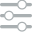
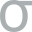
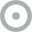
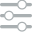
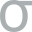
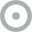
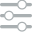
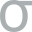
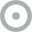
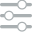
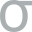
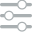
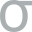
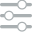
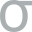
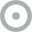
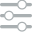
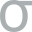
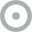
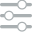
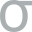
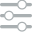
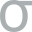

In [15]:
%autoreload
gui = CoordinateCorrectionLayout(
    calibrated_dataset=defocused_wide,
    nav_mode='point',
    sig_mode='lin',
    ctx=ctx,
    twothetas=None,
)
display(gui.layout.servable())

In [18]:
defocused_wide_calibrated = gui.current_calibrated()

Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(label='Scan rotation / degrees', name='Scan rotation / degrees')
        [1] FloatInput(label='Detector pixel p..., name='Detector pixel p..., value=59.99999999999999)
        [2] FloatInput(label='Camera length / m', name='Camera length / m', step=0.01, value=1.260250855350717)
        [3] FloatInput(label='Convergence s..., name='Convergence s..., step=0.01, value=7.0)
    [2] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['ed168766-d5e5-4478-aaef-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['96b3f1c5-39a9-4656-8d15-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(label='Record', name='Record')
            [1] Button(label='Apply correction f..., name='Apply correction f...)
            [2] Button(label='Clear', name='Clear')
            [3] Button(label='Refine correction w..., name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['42084a25-cded-4c25-ae52-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['acfc5583-2424-4291-87f7-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['0c422842-f99c-474c-aa02-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(label='Scale bar / nm', name='Scale bar / nm', step=0.01, value=np.float64(2003.7136891914...)
        [1] FloatInput(disabled=True, label='Scale bar angle / deg', name='Scale bar angle / deg')
    [7] Row
        [0] Column(margin=(3, 3))
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls
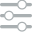
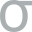
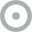
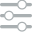
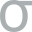
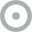
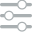
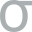
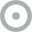
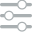
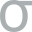
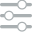
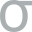
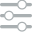
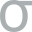
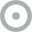
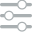
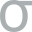
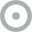
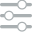
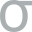
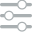
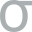

In [19]:
%autoreload
inverted_gui = CoordinateCorrectionLayout(
    calibrated_dataset=jeol_dm4.CalibratedJEOLDM4(
        path=defocused_wide_calibrated.path,
        model=defocused_wide_calibrated.model.invert_focus().normalize_types()
    ),
    nav_mode='point',
    sig_mode='lin',
    ctx=ctx,
    twothetas=None,
)
display(inverted_gui.layout.servable())